Packages loaded successfully.
NOAA output directory:
/Users/gaoyujuan/REAP Dropbox/Gao yujuan/Virginia Tech/CALS/datasets/boundaries/noaa_helene

Virginia boundary loaded successfully.
CRS: EPSG:4326
Bounds: [-83.67539511  36.5407366  -75.24245918  39.46601177]

Downloading:
https://www.nhc.noaa.gov/gis/best_track/al092024_best_track.zip
Saved to:
/Users/gaoyujuan/REAP Dropbox/Gao yujuan/Virginia Tech/CALS/datasets/boundaries/noaa_helene/al092024_best_track.zip
Extracted to:
/Users/gaoyujuan/REAP Dropbox/Gao yujuan/Virginia Tech/CALS/datasets/boundaries/noaa_helene/best_track

Extracted files:
AL092024_lin.dbf
AL092024_lin.prj
AL092024_lin.shp
AL092024_lin.shp.xml
AL092024_lin.shx
AL092024_pts.dbf
AL092024_pts.prj
AL092024_pts.shp
AL092024_pts.shp.xml
AL092024_pts.shx
AL092024_radii.dbf
AL092024_radii.prj
AL092024_radii.shp
AL092024_radii.shp.xml
AL092024_radii.shx
AL092024_windswath.dbf
AL092024_windswath.prj
AL092024_windswath.shp
AL092024_windswath.shp.xml
AL092024_windswath.shx

NO

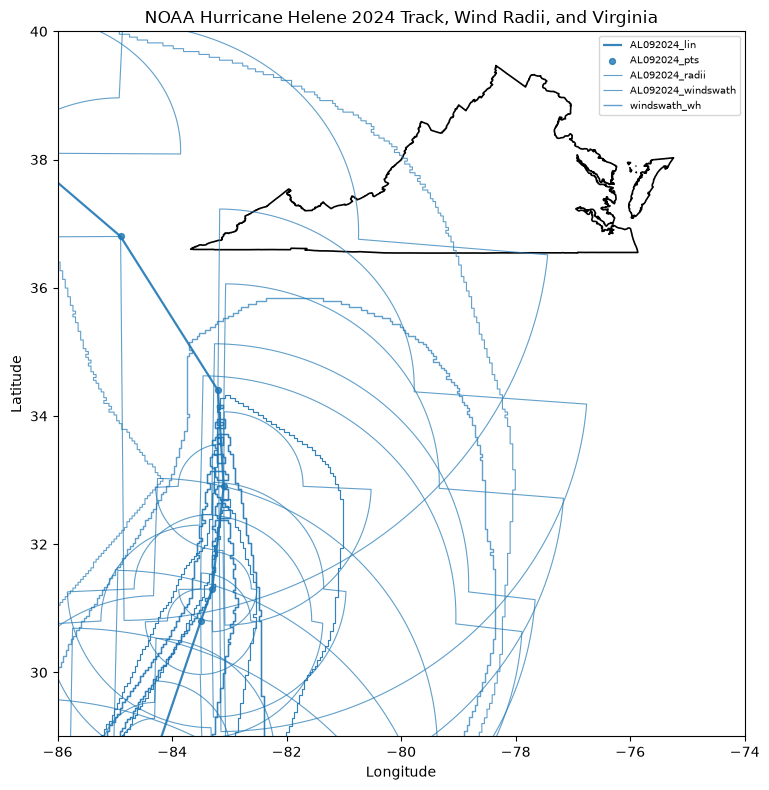


Map saved to:
/Users/gaoyujuan/REAP Dropbox/Gao yujuan/Virginia Tech/CALS/datasets/boundaries/noaa_helene/helene_noaa_virginia_context.png

Inventory saved to:
/Users/gaoyujuan/REAP Dropbox/Gao yujuan/Virginia Tech/CALS/datasets/metadata/noaa_helene_file_inventory.csv

First inventory records:
                  file_name extension  \
0   al092024_best_track.zip      .zip   
1    al092024_windswath.kmz      .kmz   
2    al092024_windswath.zip      .zip   
3          AL092024_lin.dbf      .dbf   
4          AL092024_lin.prj      .prj   
5          AL092024_lin.shp      .shp   
6      AL092024_lin.shp.xml      .xml   
7          AL092024_lin.shx      .shx   
8          AL092024_pts.dbf      .dbf   
9          AL092024_pts.prj      .prj   
10         AL092024_pts.shp      .shp   
11     AL092024_pts.shp.xml      .xml   
12         AL092024_pts.shx      .shx   
13       AL092024_radii.dbf      .dbf   
14       AL092024_radii.prj      .prj   
15       AL092024_radii.shp      .shp   
16   AL

In [1]:
# =============================================================================
# 02_download_noaa.ipynb
#
# Purpose:
# Download NOAA/NHC GIS data for Hurricane Helene (AL092024), including:
#   1. Best-track line
#   2. Storm-center points
#   3. Wind-radius polygons
#   4. Cumulative wind-swath KMZ
#
# Main output folder:
# /Users/gaoyujuan/REAP Dropbox/Gao yujuan/
# Virginia Tech/CALS/datasets/boundaries/noaa_helene/
# =============================================================================


# =============================================================================
# 1. Load packages
# =============================================================================

from pathlib import Path
import shutil
import zipfile

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import requests

print("Packages loaded successfully.")


# =============================================================================
# 2. Define project paths
# =============================================================================

BASE_DIR = Path(
    "/Users/gaoyujuan/REAP Dropbox/Gao yujuan/"
    "Virginia Tech/CALS/datasets"
)

BOUNDARIES_DIR = BASE_DIR / "boundaries"
METADATA_DIR = BASE_DIR / "metadata"

VIRGINIA_DIR = BOUNDARIES_DIR / "virginia"
NOAA_DIR = BOUNDARIES_DIR / "noaa_helene"

BEST_TRACK_DIR = NOAA_DIR / "best_track"
COMPLETE_DIR = NOAA_DIR / "complete"
VIRGINIA_OUTPUT_DIR = NOAA_DIR / "virginia"
WINDSWATH_DIR = NOAA_DIR / "windswath"

for folder in [
    BOUNDARIES_DIR,
    METADATA_DIR,
    NOAA_DIR,
    BEST_TRACK_DIR,
    COMPLETE_DIR,
    VIRGINIA_OUTPUT_DIR,
    WINDSWATH_DIR,
]:
    folder.mkdir(
        parents=True,
        exist_ok=True,
    )

print("NOAA output directory:")
print(NOAA_DIR)


# =============================================================================
# 3. Helper functions
# =============================================================================

def download_file(
    url: str,
    output_path: Path,
    overwrite: bool = False,
    timeout: int = 180,
) -> Path:
    """
    Download a file and return its local path.
    """

    output_path = Path(output_path)

    output_path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    if output_path.exists() and not overwrite:
        print(f"Already exists: {output_path}")
        return output_path

    print(f"\nDownloading:\n{url}")

    with requests.get(
        url,
        stream=True,
        timeout=timeout,
    ) as response:

        response.raise_for_status()

        with output_path.open("wb") as file:

            for chunk in response.iter_content(
                chunk_size=1024 * 1024
            ):
                if chunk:
                    file.write(chunk)

    print(f"Saved to:\n{output_path}")

    return output_path


def unzip_file(
    zip_path: Path,
    output_directory: Path,
    overwrite: bool = False,
) -> Path:
    """
    Extract a ZIP archive and return the extraction directory.
    """

    zip_path = Path(zip_path)
    output_directory = Path(output_directory)

    if output_directory.exists() and overwrite:
        shutil.rmtree(output_directory)

    output_directory.mkdir(
        parents=True,
        exist_ok=True,
    )

    with zipfile.ZipFile(
        zip_path,
        "r",
    ) as archive:

        archive.extractall(
            output_directory
        )

    print(f"Extracted to:\n{output_directory}")

    return output_directory


# =============================================================================
# 4. Load Virginia boundary
# =============================================================================

VIRGINIA_FILE = (
    VIRGINIA_DIR /
    "virginia_boundary.geojson"
)

if not VIRGINIA_FILE.exists():

    raise FileNotFoundError(
        "Virginia boundary file was not found.\n"
        "Run 01_download_virginia_boundary.ipynb first.\n\n"
        f"Expected file:\n{VIRGINIA_FILE}"
    )

virginia = gpd.read_file(
    VIRGINIA_FILE
)

if virginia.crs is None:

    virginia = virginia.set_crs(
        "EPSG:4326"
    )

else:

    virginia = virginia.to_crs(
        "EPSG:4326"
    )

print("\nVirginia boundary loaded successfully.")
print("CRS:", virginia.crs)
print("Bounds:", virginia.total_bounds)


# =============================================================================
# 5. Download NOAA/NHC Helene best-track ZIP
# =============================================================================

BEST_TRACK_URL = (
    "https://www.nhc.noaa.gov/gis/best_track/"
    "al092024_best_track.zip"
)

BEST_TRACK_ZIP = (
    NOAA_DIR /
    "al092024_best_track.zip"
)

download_file(
    url=BEST_TRACK_URL,
    output_path=BEST_TRACK_ZIP,
    overwrite=False,
)


# =============================================================================
# 6. Extract NOAA best-track ZIP
# =============================================================================

unzip_file(
    zip_path=BEST_TRACK_ZIP,
    output_directory=BEST_TRACK_DIR,
    overwrite=False,
)

print("\nExtracted files:")

for file in sorted(
    BEST_TRACK_DIR.rglob("*")
):

    if file.is_file():
        print(file.name)


# =============================================================================
# 7. Read all NOAA shapefiles
# =============================================================================

shapefiles = sorted(
    BEST_TRACK_DIR.rglob("*.shp")
)

if not shapefiles:

    raise FileNotFoundError(
        "No shapefiles were found after extracting "
        "the NOAA best-track ZIP file."
    )

noaa_layers = {}

print("\nNOAA layers:")

for shapefile in shapefiles:

    layer_name = shapefile.stem

    layer = gpd.read_file(
        shapefile
    )

    if layer.crs is None:

        print(
            f"Warning: {layer_name} has no CRS. "
            "Assigning EPSG:4326."
        )

        layer = layer.set_crs(
            "EPSG:4326"
        )

    else:

        layer = layer.to_crs(
            "EPSG:4326"
        )

    noaa_layers[layer_name] = layer

    print(
        f"{layer_name}: "
        f"{len(layer):,} records; "
        f"geometry = "
        f"{layer.geom_type.unique().tolist()}"
    )


# =============================================================================
# 8. Inspect NOAA layer attributes
# =============================================================================

for layer_name, layer in noaa_layers.items():

    print("\n" + "=" * 70)
    print(f"Layer: {layer_name}")
    print("=" * 70)

    print("Columns:")
    print(layer.columns.tolist())

    print("\nFirst records:")
    print(layer.head())


# =============================================================================
# 9. Save complete NOAA layers
# =============================================================================

GEOPACKAGE_FILE = (
    NOAA_DIR /
    "helene_2024_noaa_layers.gpkg"
)

if GEOPACKAGE_FILE.exists():
    GEOPACKAGE_FILE.unlink()

for layer_name, layer in noaa_layers.items():

    safe_layer_name = layer_name[:60]

    layer.to_file(
        GEOPACKAGE_FILE,
        layer=safe_layer_name,
        driver="GPKG",
    )

    output_geojson = (
        COMPLETE_DIR /
        f"{layer_name}.geojson"
    )

    layer.to_file(
        output_geojson,
        driver="GeoJSON",
    )

    print(f"Saved: {output_geojson.name}")

print("\nComplete NOAA layers saved to:")
print(COMPLETE_DIR)

print("\nGeoPackage saved to:")
print(GEOPACKAGE_FILE)


# =============================================================================
# 10. Select NOAA features that intersect Virginia
# =============================================================================

noaa_virginia_layers = {}

for layer_name, layer in noaa_layers.items():

    if layer.empty:

        print(
            f"{layer_name}: skipped because "
            "the layer is empty."
        )

        continue

    try:

        selected = gpd.sjoin(
            layer,
            virginia[["geometry"]],
            how="inner",
            predicate="intersects",
        )

        selected = (
            selected
            .drop(
                columns=["index_right"],
                errors="ignore",
            )
            .drop_duplicates()
            .reset_index(drop=True)
        )

    except Exception as error:

        print(
            f"Spatial join failed for {layer_name}: "
            f"{error}"
        )

        selected = layer.iloc[0:0].copy()

    noaa_virginia_layers[layer_name] = selected

    print(
        f"{layer_name}: "
        f"{len(selected):,} features intersect Virginia"
    )

    if not selected.empty:

        output_file = (
            VIRGINIA_OUTPUT_DIR /
            f"{layer_name}_virginia.geojson"
        )

        selected.to_file(
            output_file,
            driver="GeoJSON",
        )

        print(
            f"Saved Virginia layer: "
            f"{output_file.name}"
        )

print("\nVirginia-intersecting layers saved to:")
print(VIRGINIA_OUTPUT_DIR)


# =============================================================================
# 11. Download NOAA cumulative wind-swath KMZ
# =============================================================================

WINDSWATH_URL = (
    "https://www.nhc.noaa.gov/gis/best_track/"
    "al092024_windswath.kmz"
)

WINDSWATH_KMZ = (
    NOAA_DIR /
    "al092024_windswath.kmz"
)

download_file(
    url=WINDSWATH_URL,
    output_path=WINDSWATH_KMZ,
    overwrite=False,
)


# =============================================================================
# 12. Extract wind-swath KMZ
#
# A KMZ file is a ZIP archive containing one or more KML files.
# =============================================================================

WINDSWATH_ZIP = (
    NOAA_DIR /
    "al092024_windswath.zip"
)

if (
    not WINDSWATH_ZIP.exists()
    or WINDSWATH_ZIP.stat().st_size
    != WINDSWATH_KMZ.stat().st_size
):

    shutil.copy2(
        WINDSWATH_KMZ,
        WINDSWATH_ZIP,
    )

unzip_file(
    zip_path=WINDSWATH_ZIP,
    output_directory=WINDSWATH_DIR,
    overwrite=False,
)

kml_files = sorted(
    WINDSWATH_DIR.rglob("*.kml")
)

print("\nWind-swath KML files:")

for file in kml_files:
    print(file)


# =============================================================================
# 13. Attempt to convert wind-swath KML layers to GeoJSON
#
# KML support depends on the GDAL installation.
# If this section cannot read the KML, keep the KMZ and open it
# directly in QGIS or ArcGIS Pro.
# =============================================================================

wind_swath_layers = {}

if not kml_files:

    print(
        "\nNo KML files were found in the wind-swath KMZ."
    )

else:

    for kml_file in kml_files:

        try:

            available_layers = gpd.list_layers(
                kml_file
            )

            print(
                f"\nLayers in {kml_file.name}:"
            )

            print(available_layers)

            for layer_name in available_layers["name"]:

                layer = gpd.read_file(
                    kml_file,
                    layer=layer_name,
                )

                if layer.empty:
                    continue

                if layer.crs is None:

                    layer = layer.set_crs(
                        "EPSG:4326"
                    )

                else:

                    layer = layer.to_crs(
                        "EPSG:4326"
                    )

                safe_name = (
                    str(layer_name)
                    .replace(" ", "_")
                    .replace("/", "_")
                    .replace("\\", "_")
                )

                wind_swath_layers[
                    safe_name
                ] = layer

                output_file = (
                    WINDSWATH_DIR /
                    f"{safe_name}.geojson"
                )

                layer.to_file(
                    output_file,
                    driver="GeoJSON",
                )

                print(
                    f"Saved wind-swath layer: "
                    f"{output_file.name}"
                )

        except Exception as error:

            print(
                "\nThe wind-swath KMZ downloaded correctly, "
                "but GeoPandas could not read this KML "
                "with the current GDAL installation."
            )

            print("\nKeep and use the original KMZ file:")
            print(WINDSWATH_KMZ)

            print("\nError:")
            print(error)


# =============================================================================
# 14. Plot Helene data with Virginia
# =============================================================================

fig, ax = plt.subplots(
    figsize=(11, 8)
)

virginia.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=1.2,
)

for layer_name, layer in noaa_layers.items():

    if layer.empty:
        continue

    geometry_types = set(
        layer.geom_type.unique()
    )

    if geometry_types.issubset(
        {"Point", "MultiPoint"}
    ):

        layer.plot(
            ax=ax,
            markersize=18,
            alpha=0.8,
            label=layer_name,
        )

    elif geometry_types.issubset(
        {"LineString", "MultiLineString"}
    ):

        layer.plot(
            ax=ax,
            linewidth=1.6,
            alpha=0.9,
            label=layer_name,
        )

    elif geometry_types.issubset(
        {"Polygon", "MultiPolygon"}
    ):

        layer.boundary.plot(
            ax=ax,
            linewidth=0.8,
            alpha=0.7,
            label=layer_name,
        )

    else:

        layer.plot(
            ax=ax,
            alpha=0.7,
            label=layer_name,
        )


for layer_name, layer in wind_swath_layers.items():

    if layer.empty:
        continue

    geometry_types = set(
        layer.geom_type.unique()
    )

    if geometry_types.intersection(
        {"Polygon", "MultiPolygon"}
    ):

        layer.boundary.plot(
            ax=ax,
            linewidth=1,
            alpha=0.7,
            label=f"windswath_{layer_name}",
        )

    else:

        layer.plot(
            ax=ax,
            alpha=0.7,
            label=f"windswath_{layer_name}",
        )


ax.set_xlim(
    -86,
    -74,
)

ax.set_ylim(
    29,
    40,
)

ax.set_title(
    "NOAA Hurricane Helene 2024 Track, "
    "Wind Radii, and Virginia"
)

ax.set_xlabel(
    "Longitude"
)

ax.set_ylabel(
    "Latitude"
)

handles, labels = ax.get_legend_handles_labels()

if handles:

    ax.legend(
        handles,
        labels,
        fontsize=7,
        loc="best",
    )

plt.tight_layout()

MAP_FILE = (
    NOAA_DIR /
    "helene_noaa_virginia_context.png"
)

plt.savefig(
    MAP_FILE,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("\nMap saved to:")
print(MAP_FILE)


# =============================================================================
# 15. Create NOAA file inventory
# =============================================================================

inventory_records = []

for file in sorted(
    NOAA_DIR.rglob("*")
):

    if file.is_file():

        inventory_records.append(
            {
                "file_name": file.name,
                "extension": file.suffix.lower(),
                "file_path": str(file),
                "file_size_bytes": file.stat().st_size,
            }
        )

inventory = pd.DataFrame(
    inventory_records
)

INVENTORY_FILE = (
    METADATA_DIR /
    "noaa_helene_file_inventory.csv"
)

inventory.to_csv(
    INVENTORY_FILE,
    index=False,
)

print("\nInventory saved to:")
print(INVENTORY_FILE)

print("\nFirst inventory records:")
print(inventory.head(20))


# =============================================================================
# 16. Final validation
# =============================================================================

print("\n" + "=" * 70)
print("NOAA HURRICANE HELENE DOWNLOAD SUMMARY")
print("=" * 70)

print(
    f"Best-track ZIP exists: "
    f"{BEST_TRACK_ZIP.exists()}"
)

print(
    f"Wind-swath KMZ exists: "
    f"{WINDSWATH_KMZ.exists()}"
)

print(
    f"Number of best-track layers: "
    f"{len(noaa_layers)}"
)

print(
    f"Readable wind-swath layers: "
    f"{len(wind_swath_layers)}"
)

print("\nNOAA directory:")
print(NOAA_DIR)

print("\nComplete NOAA layers:")
print(COMPLETE_DIR)

print("\nVirginia-intersecting NOAA layers:")
print(VIRGINIA_OUTPUT_DIR)

print("\nWind-swath files:")
print(WINDSWATH_DIR)

print("\nNotebook completed successfully.")